# **Level 2 - Restaurant Analysis**


## Task 1: Table Booking and Online Delivery
- Determine the percentage of restaurants that offer table booking and online delivery.
- Compare average ratings of restaurants with and without table booking.
- Analyze online delivery availability across price ranges.

In [41]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

plt.style.use('ggplot')


In [42]:
# Load dataset
df = pd.read_csv('cognifyz_Dataset.csv')
df['Aggregate rating'] = pd.to_numeric(df['Aggregate rating'], errors='coerce')

print('Dataset shape:', df.shape)
display(df.head())
print('\nMissing values:')
print(df.isnull().sum())

Dataset shape: (9551, 21)


,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229



Missing values:
Restaurant ID           0
Restaurant Name         0
Country Code            0
City                    0
Address                 0
Locality                0
Locality Verbose        0
Longitude               0
Latitude                0
Cuisines                9
Average Cost for two    0
Currency                0
Has Table booking       0
Has Online delivery     0
Is delivering now       0
Switch to order menu    0
Price range             0
Aggregate rating        0
Rating color            0
Rating text             0
Votes                   0
dtype: int64


In [47]:
print(df['Has Online delivery'].head(10))
print(df['Has Online delivery'].unique())
print(df['Has Online delivery'].value_counts(dropna=False))
print(df['Has Table booking'].value_counts(dropna=False))

0    False
1    False
2    False
3    False
4    False
5    False
6    False
7    False
8    False
9    False
Name: Has Online delivery, dtype: object
[False True]
Has Online delivery
False    7100
True     2451
Name: count, dtype: int64
Has Table booking
False    8393
True     1158
Name: count, dtype: int64


Percentage with table booking: 12.12 %
Percentage with online delivery: 25.66 %

Average rating by table booking:


Has Table booking
False    2.56
True     3.44
Name: Aggregate rating, dtype: float64


Average rating by online delivery:


Has Online delivery
False    2.47
True     3.25
Name: Aggregate rating, dtype: float64

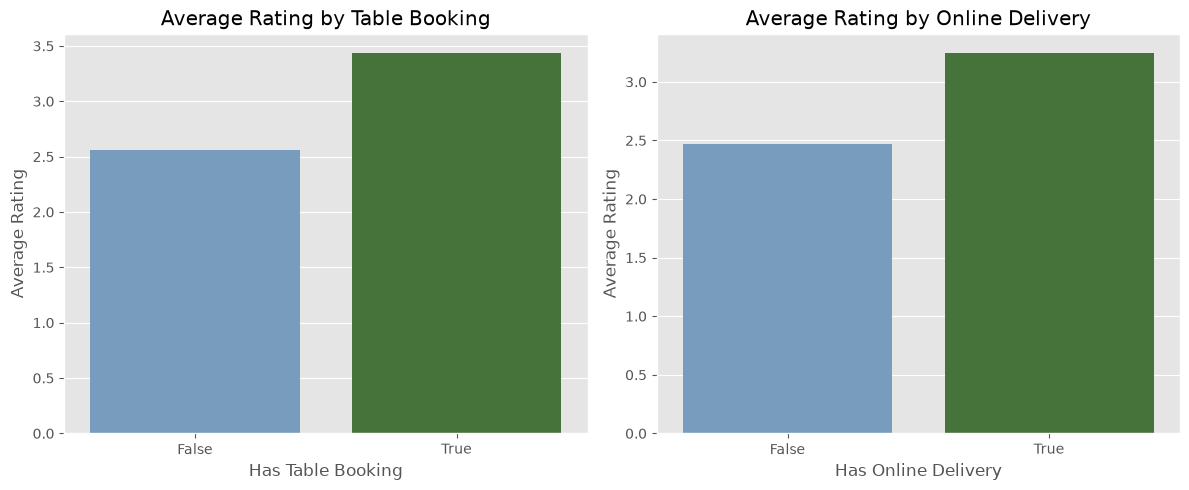


Online delivery availability by price range (%):


Has Online delivery,False,True
Price range,,
1,84.23,15.77
2,58.69,41.31
3,70.81,29.19
4,90.96,9.04


In [48]:
# Task 1

# Convert Yes/No (or existing True/False) safely
df['Has Table booking'] = (
    df['Has Table booking']
    .astype(str)
    .str.strip()
    .str.lower()
    .replace({
        'yes': True,
        'no': False,
        'true': True,
        'false': False
    })
)

df['Has Online delivery'] = (
    df['Has Online delivery']
    .astype(str)
    .str.strip()
    .str.lower()
    .replace({
        'yes': True,
        'no': False,
        'true': True,
        'false': False
    })
)

total = len(df)

table_booking_pct = (df['Has Table booking'] == True).sum() / total * 100
online_delivery_pct = (df['Has Online delivery'] == True).sum() / total * 100

print('Percentage with table booking:', round(table_booking_pct, 2), '%')
print('Percentage with online delivery:', round(online_delivery_pct, 2), '%')

rating_table = df.groupby('Has Table booking')['Aggregate rating'].mean().round(2)
rating_online = df.groupby('Has Online delivery')['Aggregate rating'].mean().round(2)

print('\nAverage rating by table booking:')
display(rating_table)

print('\nAverage rating by online delivery:')
display(rating_online)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.barplot(
    x=rating_table.index.astype(str),
    y=rating_table.values,
    hue=rating_table.index.astype(str),
    palette=['#6c9dc9', '#3f7d2f'],
    legend=False
)
plt.title('Average Rating by Table Booking')
plt.xlabel('Has Table Booking')
plt.ylabel('Average Rating')

plt.subplot(1, 2, 2)
sns.barplot(
    x=rating_online.index.astype(str),
    y=rating_online.values,
    hue=rating_online.index.astype(str),
    palette=['#6c9dc9', '#3f7d2f'],
    legend=False
)
plt.title('Average Rating by Online Delivery')
plt.xlabel('Has Online Delivery')
plt.ylabel('Average Rating')

plt.tight_layout()
plt.show()

online_by_price = pd.crosstab(
    df['Price range'],
    df['Has Online delivery'],
    normalize='index'
) * 100

print('\nOnline delivery availability by price range (%):')
display(online_by_price.round(2))

## Task 2: Price Range Analysis
- Determine the most common price range among restaurants.
- Calculate the average rating for each price range.
- Identify the color representing the highest average rating.

Most common price range: 1

Average rating by price range:


Price range
1    2.00
2    2.94
3    3.68
4    3.82
Name: Aggregate rating, dtype: float64


Highest average rating price range: 4
Color representing highest average rating: red


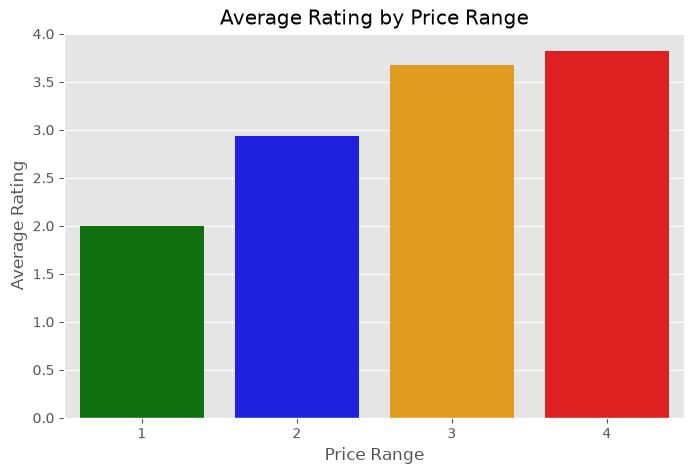

In [49]:
# Task 2 analysis
price_counts = df['Price range'].value_counts().sort_index()
most_common_price = price_counts.idxmax()
avg_rating_price = df.groupby('Price range')['Aggregate rating'].mean().round(2)

color_map = {1: 'green', 2: 'blue', 3: 'orange', 4: 'red'}
highest_price_range = int(avg_rating_price.idxmax())
highest_color = color_map.get(highest_price_range, 'gray')

print('Most common price range:', most_common_price)
print('\nAverage rating by price range:')
display(avg_rating_price)
print('\nHighest average rating price range:', highest_price_range)
print('Color representing highest average rating:', highest_color)

plt.figure(figsize=(8,5))

sns.barplot(
    x=avg_rating_price.index.astype(str),
    y=avg_rating_price.values,
    hue=avg_rating_price.index.astype(str),
    palette=[color_map.get(int(value), 'gray') for value in avg_rating_price.index],
    legend=False
)

plt.title("Average Rating by Price Range")
plt.xlabel("Price Range")
plt.ylabel("Average Rating")
plt.show()


## Task 3: Feature Engineering
- Extract new features from the restaurant name and address.
- Create binary flags for table booking and online delivery.

Engineered feature sample:


,Restaurant Name,Address,Price range,Has Table booking flag,Has Online delivery flag,Name length,Address length,Aggregate rating
0,Le Petit Souffle,"Third Floor, Century City Mall, Kalayaan Avenu...",3,NaN,NaN,16,71,4.8
1,Izakaya Kikufuji,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...",3,NaN,NaN,16,67,4.5
2,Heat - Edsa Shangri-La,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...",4,NaN,NaN,22,56,4.4
3,Ooma,"Third Floor, Mega Fashion Hall, SM Megamall, O...",4,NaN,NaN,4,70,4.9
4,Sambo Kojin,"Third Floor, Mega Atrium, SM Megamall, Ortigas...",4,NaN,NaN,11,64,4.8



New feature summary:


,Name length,Address length,Has Table booking flag,Has Online delivery flag
count,9551.00,9551.00,0.0,0.0
mean,15.16,53.54,NaN,NaN
std,6.86,17.12,NaN,NaN
min,2.00,13.00,NaN,NaN
25%,10.00,41.00,NaN,NaN
50%,14.00,52.00,NaN,NaN
75%,19.00,64.00,NaN,NaN
max,54.00,132.00,NaN,NaN


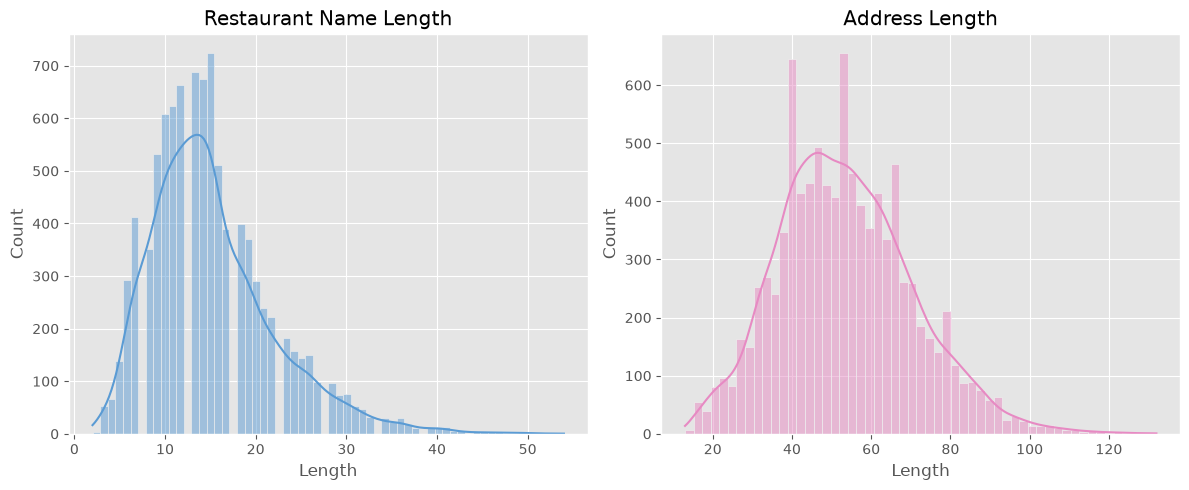

In [50]:
# Task 3: Feature Engineering

# Create new numerical features
df['Name length'] = df['Restaurant Name'].astype(str).str.len()
df['Address length'] = df['Address'].astype(str).str.len()

# Convert Yes/No to 1/0
df['Has Table booking flag'] = df['Has Table booking'].map({'Yes': 1, 'No': 0})
df['Has Online delivery flag'] = df['Has Online delivery'].map({'Yes': 1, 'No': 0})

# Create a new dataframe with engineered features
engineered = df[[
    'Restaurant Name',
    'Address',
    'Price range',
    'Has Table booking flag',
    'Has Online delivery flag',
    'Name length',
    'Address length',
    'Aggregate rating'
]]

print("Engineered feature sample:")
display(engineered.head())

print("\nNew feature summary:")
display(
    engineered[
        ['Name length',
         'Address length',
         'Has Table booking flag',
         'Has Online delivery flag']
    ].describe().round(2)
)

# Plot distributions
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df['Name length'], kde=True, color='#5a9bd4')
plt.title('Restaurant Name Length')
plt.xlabel('Length')
plt.ylabel('Count')

plt.subplot(1, 2, 2)
sns.histplot(df['Address length'], kde=True, color='#e78ac3')
plt.title('Address Length')
plt.xlabel('Length')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

## Summary
- Task 1 calculated service percentages and compared ratings.
- Task 2 identified the most common price range and highest rated price range.
- Task 3 added feature engineering columns for name and address length plus binary service flags.

## Conclusion

This analysis shows that restaurant features such as table booking and online delivery are closely related to customer ratings and pricing patterns. The findings suggest that higher-priced restaurants tend to have different service patterns, and the engineered features provide a useful foundation for further predictive modeling or deeper business insights.